# Rome Airbnb Market Analysis: Investment Opportunities
**Prepared by:** Theodoros Diomis

**Project Overview:** Analyze Rome's short-term rental market to identify high-yield real estate investment opportunities and understand local pricing dynamics. **To do** this, we are utilizing **the official Inside Airbnb dataset for Rome**. This dataset gives us a comprehensive, street-level view of the current market, including pricing, location and property types.

## Data Quality & Preprocessing

In [1]:
import pandas as pd
import plotly.express as px

# Added this for the graphs to be static
import plotly.io as pio
pio.renderers.default = "svg"

# Loading the Rome Airbnb dataset into a pandas DataFrame
data_url = 'https://data.insideairbnb.com/italy/lazio/rome/2025-09-14/visualisations/listings.csv'
df = pd.read_csv(data_url)

# Stating the overall size of the dataset
print("--- DATASET OVERVIEW ---")
print(f"Total Properties (Listings):", len(df))
print(f"Total Data Points per Property (Columns):", len(df.columns))

# Summary table to evaluate data completeness and uniqueness for each column
summary_df = pd.DataFrame({
    "Non-Null Count": df.notna().sum(),
    "Null Percentage (%)": round(df.isna().sum() / len(df) * 100),
    "Distinct Values": df.nunique()
})

display(summary_df)

--- DATASET OVERVIEW ---
Total Properties (Listings): 37652
Total Data Points per Property (Columns): 18


,Non-Null Count,Null Percentage (%),Distinct Values
id,37652,0.0,37652
name,37652,0.0,36682
host_id,37652,0.0,20523
host_name,37644,0.0,3989
neighbourhood_group,0,100.0,0
neighbourhood,37652,0.0,15
latitude,37652,0.0,23489
longitude,37652,0.0,25876
room_type,37652,0.0,4
price,33564,11.0,1041


## Data Cleaning & Preprocessing

**Columns to be dropped**
* **`id`, `host_id`** - **Dropped.**
  * *Reason:* High-cardinality unique identifiers that provide no statistical value for market analysis or predictive modeling.
* **`neighbourhood_group`** - **Dropped.**
  * *Reason:* 100% null, provides no usable data.
* **`last_review`** - **Dropped.**
  * *Reason:* This is a date format of the last review that provide no statistical value.
* **`license`** - **Dropped.**
  * *Reason:* Primarily administrative text with a high percentage of missing values.  

**Null values to be filled**
* **`reviews_per_month`** - **Filled with 0.**
  * *Reason:* The ~14% missing data logically indicates these are newer properties that have not yet been rated.

**Null values to be dropped**
* **`price`** - **Dropped.**
  * *Reason:* `price` is our primary target variable for real estate analysis. While about 11% of listings are missing price data, our current objective is Exploratory Data Analysis (EDA), not predictive machine learning. By making this cut, we still retain nearly 90% of our dataset (over 33,000 listings). This large dataset is more than enough to provide an accurate, general view of current market prices.

**Extra Assumptions:** Beyond direct data cleaning, our initial assessment provides a few valuable structural assumptions about the data. First, the low cardinality of features like `room_type` (4 distinct categories) and `neighbourhood` (15 distinct categories) makes them ideal, stable categorical variables for segmenting our visualizations and price analysis. Furthermore, comparing the 37,652 total listings against only 20,286 distinct `host_id`s reveals that many hosts operate multiple properties, allowing us to assume a strong presence of professional, commercial investors operating in the Rome market.

In [2]:
# List of columns that will be dropped
columns_drop = ['id', 'host_id', 'neighbourhood_group', 'last_review', 'license']

# New cleaned dataframe
df_cleaned = df.drop(columns = columns_drop)

# Filling missing values of reviews_per_month with 0
df_cleaned['reviews_per_month'] = df_cleaned['reviews_per_month'].fillna(0)

# Drop row with missing price value
df_cleaned = df_cleaned[df_cleaned['price'].notna()]

# Showcase the cleaning
print("--- DATA CLEANING SUMMARY ---")
print("Original columns:", len(df.columns))
print("Remaining columns:", len(df_cleaned.columns))
print("Null values in 'reviews_per_month':", df_cleaned['reviews_per_month'].isna().sum())
print("Total rows before dropping null prices:", len(df))
print("Total rows after dropping null prices:", len(df_cleaned))

--- DATA CLEANING SUMMARY ---
Original columns: 18
Remaining columns: 13
Null values in 'reviews_per_month': 0
Total rows before dropping null prices: 37652
Total rows after dropping null prices: 33564


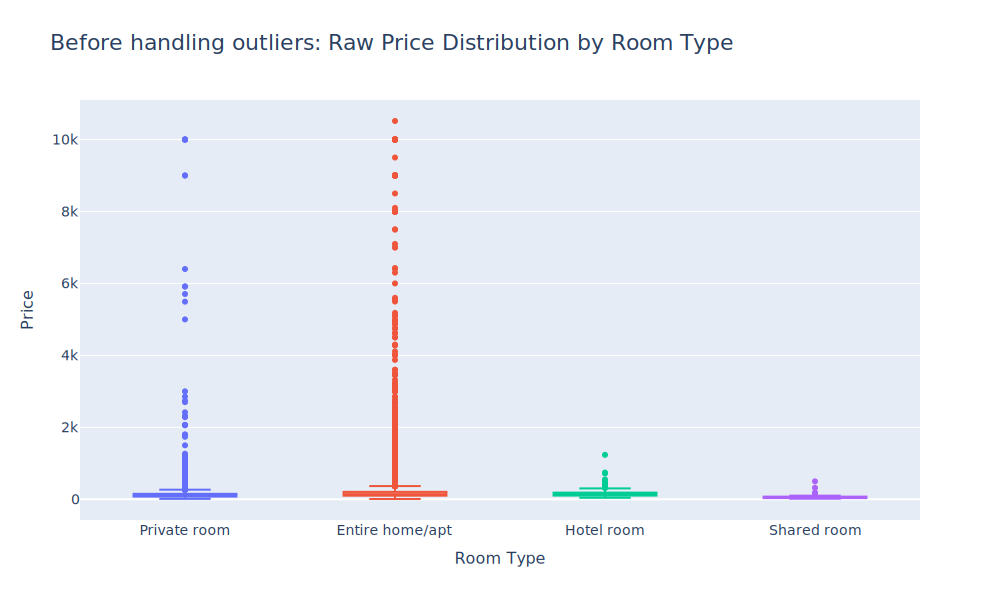

In [3]:
# A box plot to visualize the spread of prices across different room types
fig_before = px.box(
    df_cleaned,
    x="room_type",
    y="price",
    color="room_type",
    title="Before handling outliers: Raw Price Distribution by Room Type",
    # Renaming axes for clarity
    labels={"room_type": "Room Type", "price": "Price"},
    height=600,
    width=1000
)

# Refine the layout for better presentation
fig_before.update_layout(
    showlegend=False,
    title_font_size=22,
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    xaxis_tickfont_size=14,
    yaxis_tickfont_size=14
)

fig_before.show()

In [4]:
# Removing outliers and creating a list to hold the cleaned data
cleaned_pieces = []

# Iterate through each unique room type to handle outliers specific to that category
for room in df_cleaned['room_type'].unique():

    # Filter the data to look only at the current room type
    room_data = df_cleaned[df_cleaned['room_type'] == room]

    # Interquartile Range (IQR)
    Q1 = room_data['price'].quantile(0.25)
    Q3 = room_data['price'].quantile(0.75)
    IQR = Q3 - Q1

    # Define the bounds where lower bound of price cannot be a negative value
    lower_bound = max(0, Q1 - 1.5 * IQR)
    upper_bound = Q3 + 1.5 * IQR

    # Keep only prices within these bounds
    room_data_clean = room_data[(room_data['price'] >= lower_bound) & (room_data['price'] <= upper_bound)]

    # Adding the cleaned subset on the list
    cleaned_pieces.append(room_data_clean)

# Combine the cleaned subsets to a new dataframe
df_cleaned_out = pd.concat(cleaned_pieces)

print("--- OUTLIER CLEANING SUMMARY ---")
print(f"Total rows before outlier removal:", len(df_cleaned))
print(f"Total rows after outlier removal:", len(df_cleaned_out))
print(f"Total extreme outliers removed:", len(df_cleaned) - len(df_cleaned_out))

--- OUTLIER CLEANING SUMMARY ---
Total rows before outlier removal: 33564
Total rows after outlier removal: 31128
Total extreme outliers removed: 2436


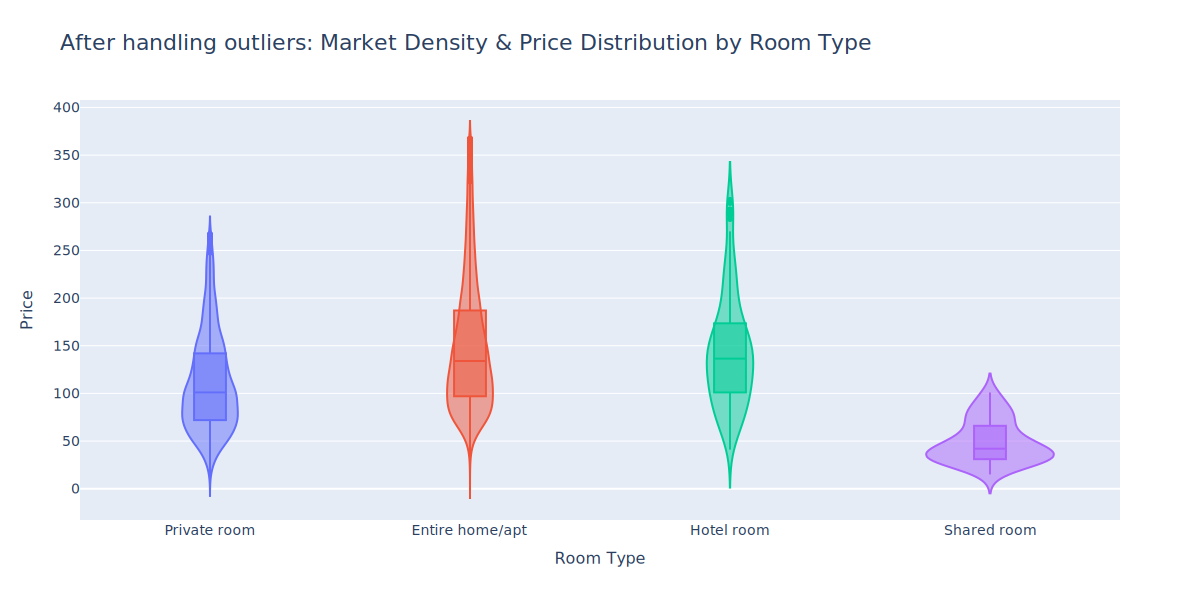

In [5]:
# Violin plot with outliers removed
fig_violin = px.violin(
    df_cleaned_out,
    x="room_type",
    y="price",
    color="room_type",
    # Boxplot inside the violin for detailed stats
    box=True,
    title="After handling outliers: Market Density & Price Distribution by Room Type",
    labels={"room_type": "Room Type", "price": "Price"},
    height=600,
    width=1200
)

fig_violin.update_layout(
    showlegend=False,
    title_font_size=22,
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    xaxis_tickfont_size=14,
    yaxis_tickfont_size=14,
)

fig_violin.show()

With statistical outliers removed, the violin plot reveals the true distribution and pricing concentration of Rome's Airbnb market.

**Key Insights:**
* **Entire home/apt (Premium & Diverse):** Commands the highest median price. The elongated shape reveals a highly diverse market spanning from standard tourist apartments to premium luxury rentals.
* **Hotel room (Standardized):** Competes with Entire Homes in median price, but the compressed shape indicates rigid, standardized pricing with minimal variance.
* **Private & Shared rooms (Budget-Focused):** Private rooms cluster heavily in the sub-€100 tier. Shared rooms exhibit the narrowest market focus, strictly anchored at the absolute lowest price points.

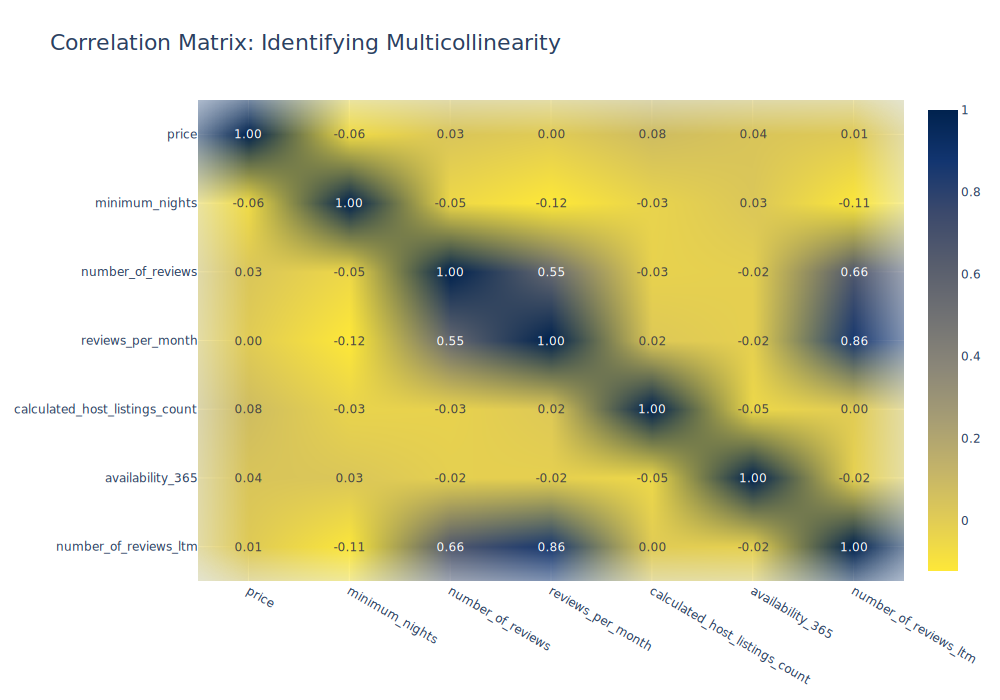

In [6]:
# We drop 'latitude' and 'longitude' because correlating coordinates doesn't make statistical sense
numeric_val = df_cleaned_out.select_dtypes(include='number').drop(columns=['latitude', 'longitude'])

# Heatmap to visualize correlation
fig_corr = px.imshow(
    # The Pearson correlation coefficient
    numeric_val.corr(),
    # Values rounded to 2 decimals
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale=px.colors.sequential.Cividis_r,
    title="Correlation Matrix: Identifying Multicollinearity"
)

fig_corr.update_layout(
    title_font_size=22,
    height=700,
    width=1000
)

fig_corr.show()

**Insights:**  
A review of the correlation matrix reveals a strong positive relationship (**0.86**) between `reviews_per_month` and `number_of_reviews_ltm` (reviews in the last twelve months), alongside a moderate-to-strong correlation (**0.66**) between `number_of_reviews_ltm` and total `number_of_reviews`. This is a clear indicator of potential **multicollinearity**, as these features capture the same underlying variance: the property's booking frequency and popularity. To prevent this redundancy from destabilizing future predictive models, it is recommended to retain only one review-based metric while dropping the others. Furthermore, the matrix shows a distinct lack of linear correlation between our target variable, `price`, and all other numerical features (with all coefficients near 0). This confirms that any future pricing model will need to rely predominantly on categorical and spatial features, such as property type and neighborhood.

## Market Composition & Geography

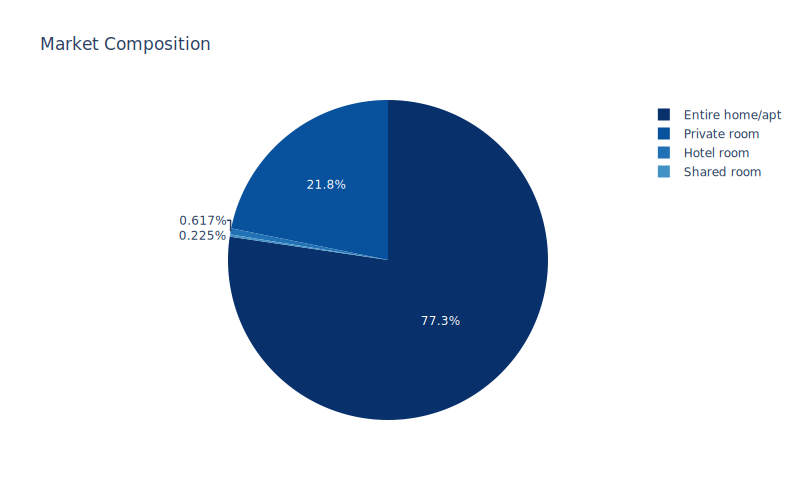

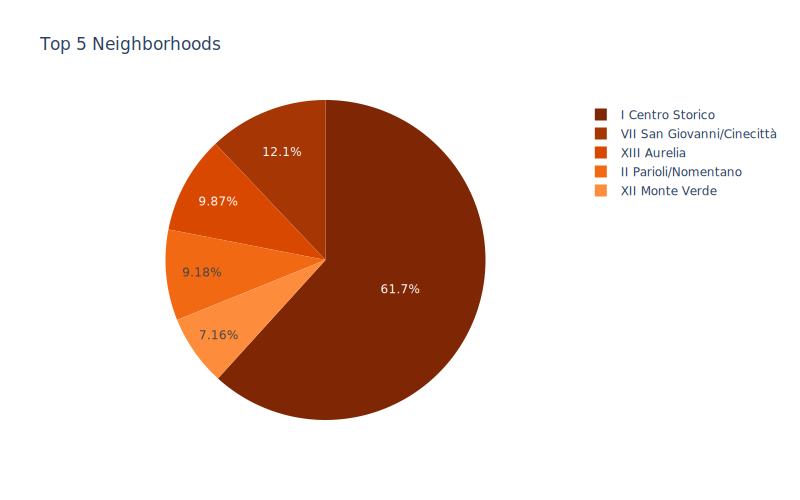

In [7]:
# Most frequent room types
room_counts = df_cleaned_out['room_type'].value_counts().reset_index()

fig_rooms = px.pie(
    room_counts,
    values='count',
    names='room_type',
    title="Market Composition",
    color_discrete_sequence=px.colors.sequential.Blues_r,
    width=800,
    height=500
)

fig_rooms.show()


# Most frequent neighbour values
neigh_counts = df_cleaned_out['neighbourhood'].value_counts().head(5).reset_index()

fig_neigh = px.pie(
    neigh_counts,
    values='count',
    names='neighbourhood',
    title="Top 5 Neighborhoods",
    color_discrete_sequence=px.colors.sequential.Oranges_r,
    width=800,
    height=500
)

fig_neigh.show()

**Key Takeaways from the Charts**

**1. Most Airbnbs are Entire Homes**
* **The Numbers:** Over three-quarters (77.3%) of Rome's Airbnb listings are entire homes or apartments. Only 21.8% are private rooms.
* **What it means:** The market is mostly made up of full-time, dedicated rental properties rather than locals just renting out a spare bedroom in the house they live in.

**2. The Historic Center is the Most Crowded**
* **The Numbers:** The Historic Center (Centro Storico) holds 61.7% of all the listings among the top 5 neighborhoods. San Giovanni is a distant second at 12.1%.
* **What it means for investors:** The Historic Center has the most demand, but it is also the most crowded and expensive place to buy. If you want to invest, looking just outside the center (like in San Giovanni) might be a smarter financial move because properties are likely cheaper to buy, but there is still plenty of tourist demand.

### Interactive map

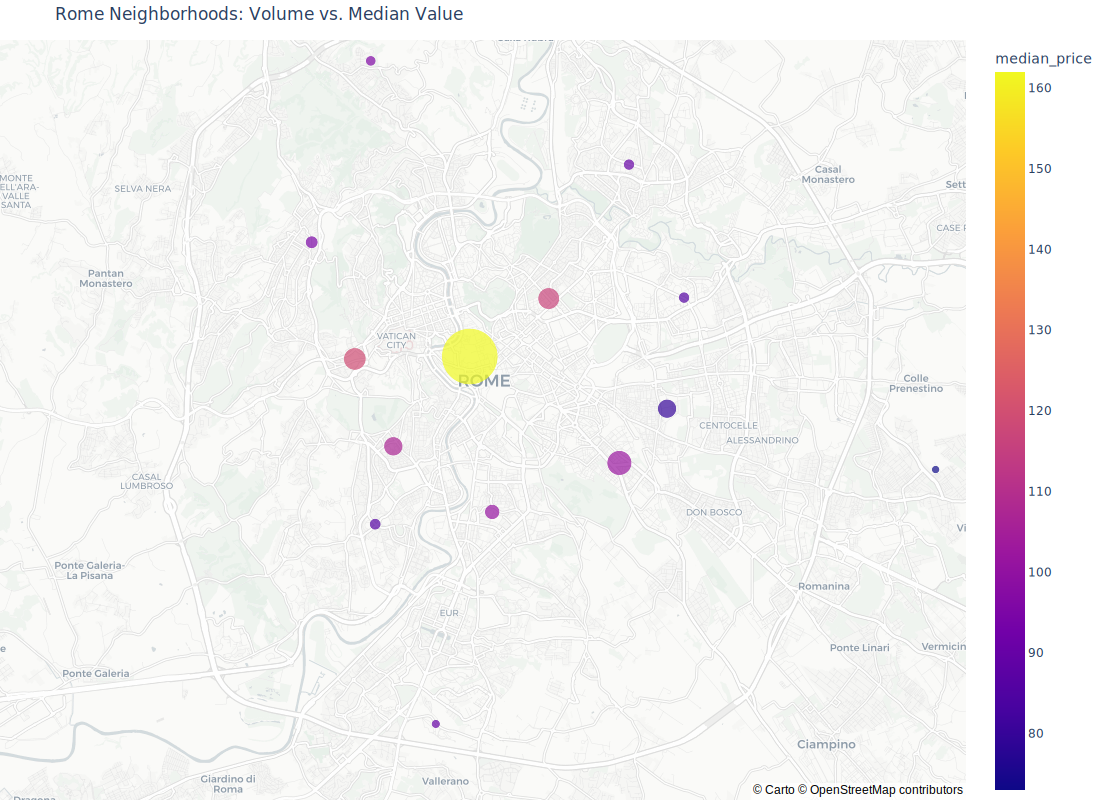

In [8]:
# Aggregate data by neighborhood to create a summary for the map
neigh_map_data = df_cleaned_out.groupby('neighbourhood').agg(
    median_price=('price', 'median'),
    total_listings=('price', 'count'),
    latitude=('latitude', 'mean'),
    longitude=('longitude', 'mean')
).reset_index()

# Interactive bubble map using Mapbox
fig_bubble = px.scatter_mapbox(
    neigh_map_data,
    lat="latitude",
    lon="longitude",
    # Bigger bubble = more properties
    size="total_listings",
    # Darker bubble = cheaper
    color="median_price",
    hover_name="neighbourhood",
    hover_data={"median_price": True, "total_listings": True, "latitude": False, "longitude": False},
    color_continuous_scale="Plasma",
    # Maximum bubble size
    size_max=40,
    zoom=11,
    mapbox_style="open-street-map",
    title="Rome Neighborhoods: Volume vs. Median Value",
    height=800,
    width=1100
)

fig_bubble.update_layout(mapbox_style="carto-positron", margin={"r":0,"t":40,"l":0,"b":0})
fig_bubble.show()

The map reveals two very different real estate markets in Rome:

* **The Historic Center:** The massive, yellow cluster show where the prices are highest. It is a highly profitable area, but heavily overcrowded and very expensive to buy into.
* **Outlying Neighborhoods:** Small, pink to purple clusters outside the main center. These are high-value neighborhoods with very little competition. Maybe a better option for investing.

## Pricing & Demand Dynamics

In [9]:
group_room_type = df_cleaned_out.groupby('room_type')

# Summary dataframe calculating the mean for financial and demand insights
market_averages = pd.DataFrame({
    "Average Price": group_room_type['price'].mean().round(2),
    "Average Total Reviews":group_room_type['number_of_reviews'].mean().round(2),
    "Average Min Nights": group_room_type['minimum_nights'].mean().round(2)
})

display(market_averages)

,Average Price,Average Total Reviews,Average Min Nights
room_type,,,
Entire home/apt,149.97,66.19,3.84
Hotel room,143.39,86.54,2.44
Private room,111.44,53.45,5.56
Shared room,49.09,34.47,5.97


* **What the data shows:** Entire homes and hotel rooms are the most expensive options (averaging 143–150 per night) and cater to shorter, quick-turnover trips. Conversely, private and shared rooms are much cheaper (49–111) but demand significantly longer minimum stays of 5.5 to 6 nights.
* **The Insight:** This reveals two very different hosting styles. Commercial operators (entire homes and hotels) maximize revenue through high nightly rates and frequent turnover. In contrast, live-in hosts (private and shared rooms) prefer the stability of longer visits to avoid the constant hassle and labor of cleaning and guest changeover.

## The Competitor Landscape

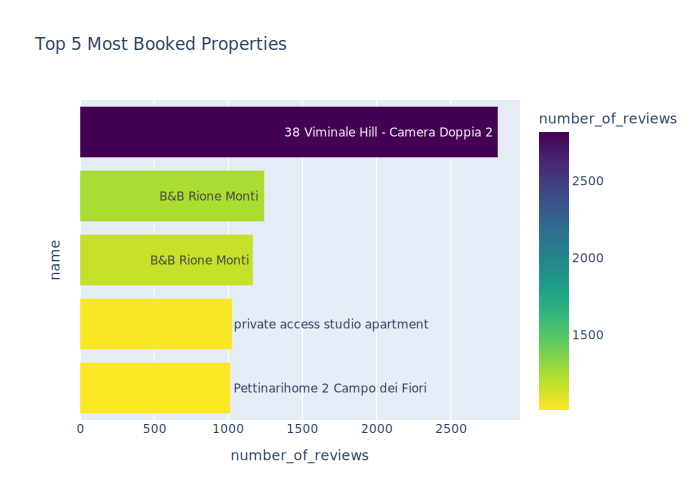

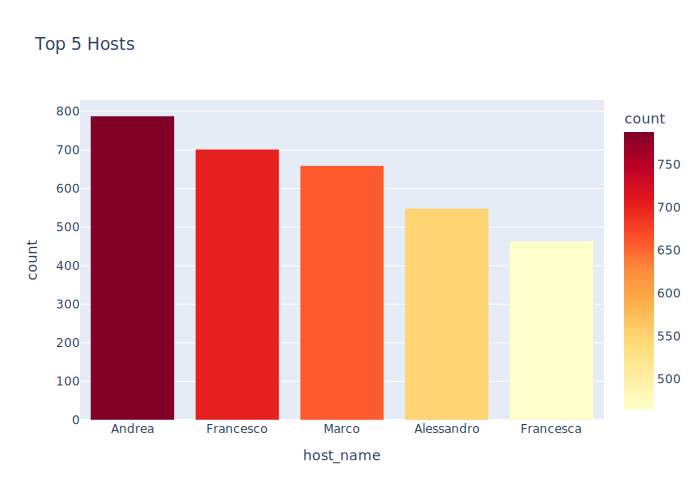

In [10]:
# Sort by number_of_reviews to find the most booked properties
top_props = df_cleaned_out.sort_values(by='number_of_reviews').tail(5)

fig_props = px.bar(
    top_props,
    x='number_of_reviews',
    y='name',
    text='name',
    orientation='h',
    color='number_of_reviews',
    color_continuous_scale='Viridis_r',
    title="Top 5 Most Booked Properties"
)


fig_props.update_yaxes(showticklabels=False)
fig_props.show()

# Calculating the frequency of each host name to find the top hosts
top_hosts = df_cleaned_out['host_name'].value_counts().head(5).reset_index()

fig_hosts = px.bar(
    top_hosts,
    x='host_name',
    y='count',
    color='count',
    color_continuous_scale='YlOrRd',
    title="Top 5 Hosts"
)

fig_hosts.show()

* **What the data shows:** A single listing ("38 Viminale Hill") is a massive outlier, dominating the market with nearly 3,000 reviews—more than double the other top properties. Meanwhile, the "Top Hosts" chart shows that the top five hosts manage massive portfolios ranging from roughly 450 to nearly 800 properties each.
* **The Insight:** Rome's short-term rental market is heavily corporatized. "Top Hosts" with hundreds of listings indicate that they probably are not individuals, but professional property management companies using common first names to appear personable.